## Data preprocessing

In [1]:
import os
import numpy as np
import cv2
from glob import glob
from tqdm import tqdm
import imageio.v2 as imageio
from albumentations import HorizontalFlip, VerticalFlip, Rotate

In [2]:
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)


def load_data(path):
    train_x = sorted(glob(os.path.join(path, "train", "images", "*.jpg")))
    train_y = sorted(glob(os.path.join(path, "train", "masks", "*.jpg")))

    test_x = sorted(glob(os.path.join(path, "test", "images", "*.jpg")))
    test_y = sorted(glob(os.path.join(path, "test", "masks", "*.jpg")))

    val_x = sorted(glob(os.path.join(path, "valid", "images", "*.jpg")))
    val_y = sorted(glob(os.path.join(path, "valid", "masks", "*.jpg")))

    return (train_x, train_y), (test_x, test_y), (val_x, val_y)


def augumentation(images, masks, save_path, augment=True):
    size = (256, 256)

    for idx, (x, y) in tqdm(enumerate(zip(images, masks)), total=len(images)):
        """Extracting the name of the file"""
        name = x.split("/")[-1].split(".")[0]

        """Reading image and mask"""
        x = cv2.imread(x, cv2.IMREAD_COLOR)
        y = imageio.imread(y)

        if augment == True:

            aug = HorizontalFlip(p=1.0)
            augmented = aug(image=x, mask=y)
            x1 = augmented["image"]
            y1 = augmented["mask"]

            aug = VerticalFlip(p=1.0)
            augmented = aug(image=x, mask=y)
            x2 = augmented["image"]
            y2 = augmented["mask"]

            aug = Rotate(limit=45, p=1.0)
            augmented = aug(image=x, mask=y)
            x3 = augmented["image"]
            y3 = augmented["mask"]

            X = [x1, x2, x3]
            Y = [y1, y2, y3]

        else:
            X = [x]
            Y = [y]

        index = 0
        for i, m in zip(X, Y):
            i = cv2.resize(i, size)
            m = cv2.resize(m, size)
            tmp_image_name = f"{name}_{index}.png"
            tmp_mask_name = f"{name}_{index}.png"

            image_path = os.path.join(save_path, "image", tmp_image_name)
            mask_path = os.path.join(save_path, "mask", tmp_mask_name)

            cv2.imwrite(image_path, i)
            cv2.imwrite(mask_path, m)

            index += 1

In [3]:
# """Seeding"""
# np.random.seed(42)

# """Load the data"""
# data_path = "/kaggle/input/datasets/soumyajitghosh1729/tnbc-dataset/TNBC-ImageMask-Dataset-V1-2"
# if not os.path.isdir(data_path):
#     raise FileNotFoundError(f"Dataset directory not found: {data_path}")
# (train_x, train_y), (test_x, test_y), (val_x, val_y) = load_data(data_path)

# print(f"Train: {len(train_x)} - {len(train_y)}")
# print(f"Test: {len(test_x)} - {len(test_y)}")
# print(f"Test: {len(val_x)} - {len(val_y)}")

# """Create Directories to sava augumented data"""
# create_dir("/dataset/train/image")
# create_dir("/dataset/train/mask")
# create_dir("/dataset/test/image")
# create_dir("/dataset/test/mask")
# create_dir("/dataset/val/image")
# create_dir("/dataset/val/mask")


# """Data Augumetation"""
# augumentation(train_x, train_y, "/dataset/train/", augment=True)
# augumentation(test_x, test_y, "/dataset/test/", augment=False)
# augumentation(val_x, val_y, "/dataset/val/", augment=False)

## Training

In [4]:
import os
import random
import numpy as np
import torch
from glob import glob
import time

import torch
from torch.utils.data import DataLoader
import torch.nn as nn
# from  segmentation_models_pytorch import Unet
import numpy as np
import pandas as pd

In [5]:
import os
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset

class DataDrive(Dataset):
    def __init__(self, images_path, masks_path):

        self.images_path = images_path
        self.masks_path = masks_path
        self.n_samples = len(images_path)

    def __getitem__(self, index):
        """ Reading image """
        image = cv2.imread(self.images_path[index], cv2.IMREAD_COLOR)
        image = image/255.0 ## (512, 512, 3)
        image = np.transpose(image, (2, 0, 1))  ## (3, 512, 512)
        image = image.astype(np.float32)
        image = torch.from_numpy(image)

        """ Reading mask """
        mask = cv2.imread(self.masks_path[index], cv2.IMREAD_GRAYSCALE)
        mask = mask/255.0   ## (512, 512)
        mask = np.expand_dims(mask, axis=0) ## (1, 512, 512)
        mask = mask.astype(np.float32)
        mask = torch.from_numpy(mask)

        return image, mask

    def __len__(self):
        return self.n_samples

In [6]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset
from scipy import ndimage
from scipy.ndimage import zoom
from torch.utils.data import Dataset
import torch
import torchvision.ops
from torch import nn

################################### DAUNet #####################################

###########################################
class DeformableConv2d(nn.Module):
    def __init__(self,
                 in_channels,
                 out_channels,
                 kernel_size=3,
                 stride=1,
                 padding=1,
                 bias=False):

        super(DeformableConv2d, self).__init__()

        self.padding = padding
        
        self.offset_conv = nn.Conv2d(in_channels, 
                                     2 * kernel_size * kernel_size,
                                     kernel_size=kernel_size, 
                                     stride=stride,
                                     padding=self.padding, 
                                     bias=True)

        nn.init.constant_(self.offset_conv.weight, 0.)
        nn.init.constant_(self.offset_conv.bias, 0.)
        
        self.modulator_conv = nn.Conv2d(in_channels, 
                                     1 * kernel_size * kernel_size,
                                     kernel_size=kernel_size, 
                                     stride=stride,
                                     padding=self.padding, 
                                     bias=True)

        nn.init.constant_(self.modulator_conv.weight, 0.)
        nn.init.constant_(self.modulator_conv.bias, 0.)
        
        self.regular_conv = nn.Conv2d(in_channels=in_channels,
                                      out_channels=out_channels,
                                      kernel_size=kernel_size,
                                      stride=stride,
                                      padding=self.padding,
                                      bias=bias)
    
    def forward(self, x):
        h, w = x.shape[2:]
        max_offset = max(h, w)/4.

        offset = self.offset_conv(x).clamp(-max_offset, max_offset)
        modulator = 2. * torch.sigmoid(self.modulator_conv(x))
        
        x = torchvision.ops.deform_conv2d(input=x, 
                                          offset=offset, 
                                          weight=self.regular_conv.weight, 
                                          bias=self.regular_conv.bias, 
                                          padding=self.padding,
                                          mask=modulator
                                          )
        return x
###########################################################################
class simam_module(torch.nn.Module):
    def __init__(self, channels=None, e_lambda=1e-4):
        super(simam_module, self).__init__()
        self.activaton = nn.Sigmoid()
        self.e_lambda = e_lambda

    def __repr__(self):
        s = self.__class__.__name__ + '('
        s += ('lambda=%f)' % self.e_lambda)
        return s

    @staticmethod
    def get_module_name():
        return "simam"

    def forward(self, x):
        b, c, h, w = x.size()
        n = w * h - 1

        x_minus_mu_square = (x - x.mean(dim=[2,3], keepdim=True)).pow(2)
        y = x_minus_mu_square / (4 * (x_minus_mu_square.sum(dim=[2,3], keepdim=True) / n + self.e_lambda)) + 0.5

        return x * self.activaton(y)


########################
class Bottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super(Bottleneck, self).__init__()
        mid_channels = out_channels // 4  # Bottleneck compression

        padding = kernel_size // 2  # DAUNet log 1-3 > padding=1 for kernel_size=3 only. Later updated padding to be dynamic with kernal size, essentially the same for kernel_size=3.

        print("DAUNet Bottleneck Convkernel size:", kernel_size)

        self.bottleneck = nn.Sequential(
            nn.Conv2d(in_channels, mid_channels, kernel_size=kernel_size, padding=padding),  # 1x1 conv to reduce dims
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),

            DeformableConv2d(mid_channels, mid_channels, kernel_size=kernel_size, padding=padding),  # Replace with your deformable conv
            nn.BatchNorm2d(mid_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(mid_channels, out_channels, kernel_size=kernel_size, padding=padding),  # 1x1 conv to restore dims
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.bottleneck(x)


########################3
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_op = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_op(x)

class DoubleConv_DCV(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv_op = nn.Sequential(
            DeformableConv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            DeformableConv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv_op(x)

    #########################################################
class DownSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)

        return down, p
    
class DownSample_Dcv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv_DCV(in_channels, out_channels)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        down = self.conv(x)
        p = self.pool(down)

        return down, p
    ##########################################################
class UpSample(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels//2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        x = torch.cat([x1, x2], 1)
        return self.conv(x)

class DAUNet(nn.Module):
    def __init__(self, in_channels=3, num_classes=1, btlnk_kernel=3):
        super().__init__()
        self.down_convolution_1 = DownSample(in_channels, 64)
        self.down_convolution_2 = DownSample(64, 128)
        self.down_convolution_3 = DownSample(128, 256)
#         self.down_convolution_3 = DownSample_Dcv(128, 256) #### this is my model Dcv
        self.down_convolution_4 = DownSample(256, 512)
        
        self.simam_1 = simam_module()  # for down_1
        self.simam_2 = simam_module()  # for down_2
        self.simam_3 = simam_module()  # for down_3
        self.simam_4 = simam_module()  # for down_4
        
        self.bottle_neck = nn.Sequential(
            Bottleneck(512, 1024, kernel_size=btlnk_kernel),
            simam_module()
        )

        self.up_convolution_1 = UpSample(1024, 512)
        self.up_convolution_2 = UpSample(512, 256)
        self.up_convolution_3 = UpSample(256, 128)
        self.up_convolution_4 = UpSample(128, 64)

        self.out = nn.Conv2d(in_channels=64, out_channels=num_classes, kernel_size=1)
    def forward(self, x):
        down_1, p1 = self.down_convolution_1(x)
        down_2, p2 = self.down_convolution_2(p1)
        down_3, p3 = self.down_convolution_3(p2)
        down_4, p4 = self.down_convolution_4(p3)

        b = self.bottle_neck(p4)

        # Apply SIMAM to skip connections
        sim_down_4 = self.simam_4(down_4)
        sim_down_3 = self.simam_3(down_3)
        sim_down_2 = self.simam_2(down_2)
        sim_down_1 = self.simam_1(down_1)

        up_1 = self.up_convolution_1(b, sim_down_4)
        up_2 = self.up_convolution_2(up_1, sim_down_3)
        up_3 = self.up_convolution_3(up_2, sim_down_2)
        up_4 = self.up_convolution_4(up_3, sim_down_1)

        out = self.out(up_4)
        return out


In [7]:
#!pip install torchinfo -q
from torchinfo import summary

# model summary
model = DAUNet()
summary(model, input_size=(1, 3, 640, 640), col_names=["input_size", "output_size", "num_params", "kernel_size"])

DAUNet Bottleneck Convkernel size: 3


Layer (type:depth-idx)                        Input Shape               Output Shape              Param #                   Kernel Shape
DAUNet                                        [1, 3, 640, 640]          [1, 1, 640, 640]          --                        --
├─DownSample: 1-1                             [1, 3, 640, 640]          [1, 64, 640, 640]         --                        --
│    └─DoubleConv: 2-1                        [1, 3, 640, 640]          [1, 64, 640, 640]         --                        --
│    │    └─Sequential: 3-1                   [1, 3, 640, 640]          [1, 64, 640, 640]         38,720                    --
│    └─MaxPool2d: 2-2                         [1, 64, 640, 640]         [1, 64, 320, 320]         --                        2
├─DownSample: 1-2                             [1, 64, 320, 320]         [1, 128, 320, 320]        --                        --
│    └─DoubleConv: 2-3                        [1, 64, 320, 320]         [1, 128, 320, 320]        --  

In [8]:
import os
import time
from glob import glob

import torch
from torch.utils.data import DataLoader
import torch.nn as nn
from tqdm import tqdm

class Model_Training():
  def __init__(self, model, train_loader, test_loader, optimizer, device, loss_fn):
    self.train_loader = train_loader
    self.test_loader = test_loader
    self.model = model
    self.optimizer = optimizer
    self.device = device
    self.loss_fn = loss_fn
  
  def train(self):
    epoch_loss = 0.0
    self.model.train()
    for x, y in tqdm(self.train_loader):
        x = x.to(self.device, dtype=torch.float32)
        y = y.to(self.device, dtype=torch.float32)

        self.optimizer.zero_grad()
        y_prediction = self.model(x)
        loss = self.loss_fn(y_prediction,y)
        loss.backward()
        self.optimizer.step()
        epoch_loss +=loss.item()
    epoch_loss = epoch_loss/len(self.train_loader)
    return epoch_loss
  
  def evaluate(self):

    epoch_loss = 0.0
    self.model.eval()

    with torch.no_grad():
        for x, y in self.test_loader:
            x = x.to(self.device, dtype=torch.float32)
            y = y.to(self.device, dtype=torch.float32)

            y_pred = self.model(x)
            loss = self.loss_fn(y_pred, y)
            epoch_loss += loss.item()

        epoch_loss = epoch_loss/len(self.test_loader)
    return epoch_loss

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class DiceLoss(nn.Module):
    def __init__(self, weight = None, size_average=True):
        super(DiceLoss, self).__init__()

    def forward(self, inputs, targets, smooth_size=1):

        """comment out if your model contains a sigmoid or equivalent activation layer"""
        inputs = torch.sigmoid(inputs)

        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs*targets).sum()
        dice_loss = (2.*intersection + smooth_size)/(inputs.sum() + targets.sum() + smooth_size)

        return 1-dice_loss
    
class DiceBCELoss(nn.Module):
    def __init__(self, weight = None, size_average = True):
        super(DiceBCELoss, self).__init__()
    
    def forward(self, inputs, targets, smooth_size = 1):
        
        inputs = torch.sigmoid(inputs)
        
        inputs = inputs.view(-1)
        targets = targets.view(-1)
        
        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2. * intersection + smooth_size) / (inputs.sum() + targets.sum() + smooth_size)
        BCE = F.binary_cross_entropy(inputs, targets, reduction='mean')
        Dice_BCE = BCE + dice_loss

        return Dice_BCE

In [10]:
""" Seeding the randomness. """
def seeding(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

""" Create a directory. """
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

""" Calculate the time taken """
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [11]:
""" seeding"""
seeding(42)

"""Directories"""
create_dir("/kaggle/working/files")
create_dir("/kaggle/working/train_data")
data_root = "/kaggle/input/datasets/soumyajitghosh1729/tnbc-dataset/TNBC-ImageMask-Dataset-V1-2/"

"""Loading Data"""

train_x = sorted(glob(f"{data_root}/train/images/*"))
train_y = sorted(glob(f"{data_root}/train/masks/*"))

valid_x = sorted(glob(f"{data_root}/valid/images/*"))
valid_y = sorted(glob(f"{data_root}/valid/masks/*"))

if len(train_x) == 0 or len(valid_x) == 0:
    raise RuntimeError(f"No training data found under {data_root}. Run the augmentation/export cells first.")

data_ = f"Dataset size:\nTrain: {len(train_x)} - Valid: {len(valid_x)}\n"
print(data_)

"""Hyper parameters"""
size = (512, 512)
batch_size = 6
epochs = 10
learning_rate = 1e-4

"""Boolean to set whether the encder is trained or not"""
pre_trained = False


""" Dataset and loader"""

train_data = DataDrive(train_x, train_y)
valid_data = DataDrive(valid_x, valid_y)

train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, num_workers=2)
valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size, shuffle=False, num_workers=2)

encoders = ["None"]

#encoders = [ "densenet121", "densenet201"]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Dataset size:
Train: 880 - Valid: 165

Using device: cuda


In [12]:
for encoder_name in encoders:

    model = DAUNet()
    model_name = "DAUNet_"+ encoder_name
    checkpoint_path = "/kaggle/working/files/" + model_name +".pth"
    model = model.to(device)
    
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        print(f"using {torch.cuda.device_count()} devices parallely")

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5) 
    loss_function = DiceBCELoss()

    """ Training the model """
    best_valid_loss = float("inf")

    losses_values  = np.array(["epoch", "Train", "Test"])

    M = Model_Training(model, train_loader, valid_loader, optimizer, device, loss_function)

    for epoch in range(epochs):
        start_time = time.time()

        train_loss = M.train()
        valid_loss = M.evaluate() 

        """ Saving the model """
        if valid_loss < best_valid_loss:
            data_str = f"Valid loss improved from {best_valid_loss:2.4f} to {valid_loss:2.4f}. Saving checkpoint: {checkpoint_path}"
            print(data_str)

            best_valid_loss = valid_loss
            torch.save(model.state_dict(), checkpoint_path)

        end_time = time.time()
        epoch_mins, epoch_secs = epoch_time(start_time, end_time)

        data_str = f'Epoch: {epoch + 1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s\n'
        data_str += f'\tTrain Loss: {train_loss:.3f}\n'
        data_str += f'\t Val. Loss: {valid_loss:.3f}\n'
        losses_values = np.vstack((losses_values, np.array([epoch, train_loss, valid_loss])))
        print(data_str)
    C = pd.Index(["Epoch", "Train", "Valid"], name="columns")
    df = pd.DataFrame(data=losses_values, columns=C)
    df.drop(index=df.index[0], axis=0, inplace=True)
    csv_path = "/kaggle/working/train_data/" + model_name + ".csv"
    df.to_csv(csv_path, index=False)

DAUNet Bottleneck Convkernel size: 3
using 2 devices parallely


100%|██████████| 147/147 [03:38<00:00,  1.49s/it]


Valid loss improved from inf to 3.8484. Saving checkpoint: /kaggle/working/files/DAUNet_None.pth
Epoch: 01 | Epoch Time: 3m 57s
	Train Loss: 0.952
	 Val. Loss: 3.848



100%|██████████| 147/147 [03:50<00:00,  1.57s/it]


Valid loss improved from 3.8484 to 0.6561. Saving checkpoint: /kaggle/working/files/DAUNet_None.pth
Epoch: 02 | Epoch Time: 4m 9s
	Train Loss: 0.591
	 Val. Loss: 0.656



...

Valid loss improved from 0.4674 to 0.4226. Saving checkpoint: /kaggle/working/files/DAUNet_None.pth
Epoch: 08 | Epoch Time: 4m 9s
	Train Loss: 0.387
	 Val. Loss: 0.423



100%|██████████| 147/147 [03:50<00:00,  1.57s/it]


Epoch: 09 | Epoch Time: 4m 10s
	Train Loss: 0.372
	 Val. Loss: 0.587



100%|██████████| 147/147 [03:50<00:00,  1.57s/it]


Valid loss improved from 0.4226 to 0.3942. Saving checkpoint: /kaggle/working/files/DAUNet_None.pth
Epoch: 10 | Epoch Time: 4m 10s
	Train Loss: 0.353
	 Val. Loss: 0.394



## Evaluation

In [13]:
import os, time
from operator import add
import numpy as np
from glob import glob
import cv2
from tqdm import tqdm
import random
import imageio
import torch
# from  segmentation_models_pytorch import Unet
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, precision_score, recall_score

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import json

def calculate_metrics(y_true, y_pred):
    """ Ground truth """
    y_true = y_true.cpu().numpy()
    y_true = y_true > 0.5
    y_true = y_true.astype(np.uint8)
    y_true = y_true.reshape(-1)

    """ Prediction """
    y_pred = y_pred.cpu().numpy()
    y_pred = y_pred > 0.5
    y_pred = y_pred.astype(np.uint8)
    y_pred = y_pred.reshape(-1)

    score_jaccard = jaccard_score(y_true, y_pred)
    score_f1 = f1_score(y_true, y_pred)
    score_recall = recall_score(y_true, y_pred)
    score_precision = precision_score(y_true, y_pred)
    score_acc = accuracy_score(y_true, y_pred)

    return [score_jaccard, score_f1, score_recall, score_precision, score_acc]

def mask_parse(mask):
    mask = np.expand_dims(mask, axis=-1)    ## (512, 512, 1)
    mask = np.concatenate([mask, mask, mask], axis=-1)  ## (512, 512, 3)
    return mask

""" Seeding the randomness. """
def seeding(seed):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

""" Create a directory. """
def create_dir(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [14]:
import time
import os
import cv2
import torch
import numpy as np
import pandas as pd
from glob import glob
from tqdm import tqdm
from operator import add
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, jaccard_score, precision_score, recall_score
from scipy.spatial.distance import directed_hausdorff

def calculate_metrics(y_true, y_pred):
    """ Ground truth """
    y_true_np = y_true.cpu().numpy() > 0.5
    y_true_flat = y_true_np.astype(np.uint8).reshape(-1)

    """ Prediction """
    y_pred_np = y_pred.cpu().numpy() > 0.5
    y_pred_flat = y_pred_np.astype(np.uint8).reshape(-1)

    score_jaccard = jaccard_score(y_true_flat, y_pred_flat)
    score_f1 = f1_score(y_true_flat, y_pred_flat)
    score_recall = recall_score(y_true_flat, y_pred_flat)
    score_precision = precision_score(y_true_flat, y_pred_flat)
    score_acc = accuracy_score(y_true_flat, y_pred_flat)
    
    """ Hausdorff Distance """
    yt = np.squeeze(y_true_np)
    yp = np.squeeze(y_pred_np)
    yt_coords = np.argwhere(yt)
    yp_coords = np.argwhere(yp)
    
    if len(yt_coords) == 0 or len(yp_coords) == 0:
        # Penalize fully if one mask is empty and the other isn't. Diagonal distance.
        hd = 0.0 if len(yt_coords) == len(yp_coords) else np.sqrt(yt.shape[0]**2 + yt.shape[1]**2)
    else:
        d1 = directed_hausdorff(yt_coords, yp_coords)[0]
        d2 = directed_hausdorff(yp_coords, yt_coords)[0]
        hd = max(d1, d2)

    return [score_jaccard, score_f1, score_recall, score_precision, score_acc, hd]


""" Seeding """
seeding(42)

output_root = "/kaggle/working/"
cache_root = "/kaggle/working/"

""" Folders """
create_dir(f"{output_root}/results")

""" Load dataset """
test_x = sorted(glob("/kaggle/input/datasets/soumyajitghosh1729/tnbc-dataset/TNBC-ImageMask-Dataset-V1-2/test/images/*"))
test_y = sorted(glob("/kaggle/input/datasets/soumyajitghosh1729/tnbc-dataset/TNBC-ImageMask-Dataset-V1-2/test/masks/*"))

H = 640
W = 640
size = (W, H)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
encoders = ["None"]
summary_metrics = []

for encoder_name in encoders:
    checkpoint_path = f"{cache_root}/files/DAUNet_{encoder_name}.pth"
    if encoder_name == "None":
        model = DAUNet()
    
    model = model.to(device)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
        print(f"using {torch.cuda.device_count()} devices parallely")
    
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    model.eval()
    model_name = "DAUNet_" + encoder_name

    # Tracking 6 metrics now: Jaccard, F1, Recall, Precision, Accuracy, Hausdorff
    metrics_score = [0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
    time_taken = []

    for i, (x, y) in tqdm(enumerate(zip(test_x, test_y)), total=len(test_x), desc=f"Evaluating {model_name}"):
        name = x.split("/")[-1].split(".")[0]

        image = cv2.imread(x, cv2.IMREAD_COLOR) 
        x = np.transpose(image, (2, 0, 1))      
        x = x / 255.0
        x = np.expand_dims(x, axis=0).astype(np.float32)
        x = torch.from_numpy(x).to(device)

        mask = cv2.imread(y, cv2.IMREAD_GRAYSCALE)  
        y = np.expand_dims(mask, axis=0)            
        y = y / 255.0
        y = np.expand_dims(y, axis=0).astype(np.float32)
        y = torch.from_numpy(y).to(device)

        with torch.no_grad():
            start_time = time.time()
            pred_y = model(x)
            pred_y = torch.sigmoid(pred_y)
            time_taken.append(time.time() - start_time)

            score = calculate_metrics(y, pred_y)
            metrics_score = list(map(add, metrics_score, score))
            
            pred_y_parsed = (np.squeeze(pred_y[0].cpu().numpy(), axis=0) > 0.5).astype(np.uint8)

        # Image saving
        ori_mask = mask_parse(mask)
        pred_y_saved = mask_parse(pred_y_parsed) * 255
        
        image_b = cv2.copyMakeBorder(image, 30, 0, 0, 0, cv2.BORDER_CONSTANT, value=[255, 255, 255])
        ori_mask_b = cv2.copyMakeBorder(ori_mask, 30, 0, 0, 0, cv2.BORDER_CONSTANT, value=[255, 255, 255])
        pred_y_b = cv2.copyMakeBorder(pred_y_saved, 30, 0, 0, 0, cv2.BORDER_CONSTANT, value=[255, 255, 255])
        
        cv2.putText(image_b, model_name, (1,20), cv2.FONT_HERSHEY_SIMPLEX, 0.40, (0,0,0), 1, cv2.LINE_AA, False)
        cv2.putText(image_b, "Original", (160,20), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,0,0), 2, cv2.LINE_AA, False)
        cv2.putText(ori_mask_b, model_name, (1,20), cv2.FONT_HERSHEY_SIMPLEX, 0.40, (0,0,0), 1, cv2.LINE_AA, False)
        cv2.putText(ori_mask_b, "Ground Truth", (160,20), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,0,0), 2, cv2.LINE_AA, False)
        cv2.putText(pred_y_b, model_name, (1,20), cv2.FONT_HERSHEY_SIMPLEX, 0.40, (0,0,0), 1, cv2.LINE_AA, False)
        cv2.putText(pred_y_b, "Prediction", (160,20), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0,0,0), 2, cv2.LINE_AA, False)

        line = np.ones((image_b.shape[0], 10, 3)) * 128
        cat_images = np.concatenate([image_b, line, ori_mask_b, line, pred_y_b], axis=1)
        
        create_dir(f"{output_root}/results/{model_name}")
        cv2.imwrite(f"{output_root}/results/{model_name}/{name}.png", cat_images)

    """ Average Metrics """
    n = len(test_x)
    clean_encoder = model_name.replace("DAUNet_", "")
    
    summary_metrics.append({
        "Encoder": clean_encoder,
        "Jaccard": metrics_score[0] / n,
        "F1": metrics_score[1] / n,
        "Recall": metrics_score[2] / n,
        "Precision": metrics_score[3] / n,
        "Accuracy": metrics_score[4] / n,
        "Hausdorff": metrics_score[5] / n,  # Added Hausdorff!
        "FPS": 1 / np.mean(time_taken)
    })

""" Present Metrics in Simple Text Table """
df_summary = pd.DataFrame(summary_metrics)
df_summary.to_csv(f"{output_root}/results/metrics_a.csv", index=False)

print("\n" + "="*85)
print("STANDARD EVALUATION METRICS SUMMARY")
print("="*85)
# Print natively as simple text tabular format
try:
    print(df_summary.to_markdown(index=False, floatfmt=".4f"))
except ImportError:
    # Fallback to string if tabulate is not installed
    print(df_summary.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*85)


DAUNet Bottleneck Convkernel size: 3
using 2 devices parallely


Evaluating DAUNet_None: 100%|██████████| 55/55 [00:32<00:00,  1.70it/s]


STANDARD EVALUATION METRICS SUMMARY
| Encoder   |   Jaccard |     F1 |   Recall |   Precision |   Accuracy |   Hausdorff |     FPS |
|:----------|----------:|-------:|---------:|------------:|-----------:|------------:|--------:|
| None      |    0.6222 | 0.7614 |   0.7108 |      0.8311 |     0.9536 |     77.5374 | 56.7276 |


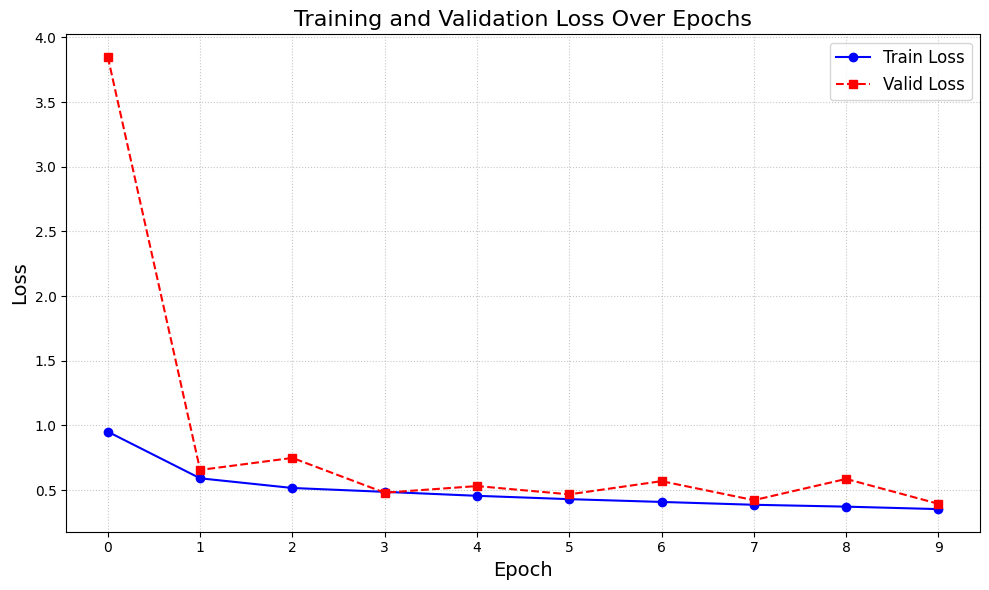

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


encoders = ["None"]

create_dir(f"{output_root}/assets")

# Plotting training and validation loss using standard matplotlib line plots
plt.figure(figsize=(10, 6))
for encoder_name in encoders:
    model_name = "DAUNet_" + encoder_name
    df = pd.read_csv(f"{cache_root}/train_data/"+model_name+".csv")
    
    plt.plot(df["Epoch"], df["Train"], label="Train Loss", linestyle='-', marker='o', color='b')
    plt.plot(df["Epoch"], df["Valid"], label="Valid Loss", linestyle='--', marker='s', color='r')

plt.title("Training and Validation Loss Over Epochs", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.ylabel("Loss", fontsize=14)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(loc='upper right', fontsize=12)
plt.tight_layout()
plt.savefig(f"{output_root}/assetsLoss_Curves.png", dpi=300)
plt.show()

# Evaluation metrics summary
# fig, ax = plt.subplots(figsize=(10, 6))
# results = pd.read_csv(f"{output_root}/results/metrics.csv")
# sns.barplot(x="Encoder", y="Value", hue="score category", data=results, palette="viridis")
# plt.title("Evaluation Metrics Summary", fontsize=16)
# plt.xlabel("Encoder", fontsize=14)
# plt.ylabel("Score", fontsize=14)
# plt.xticks(rotation=45)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.savefig(f"/kaggle/working/assets/metrics.png", dpi=300)
# plt.show()


## Visualisation

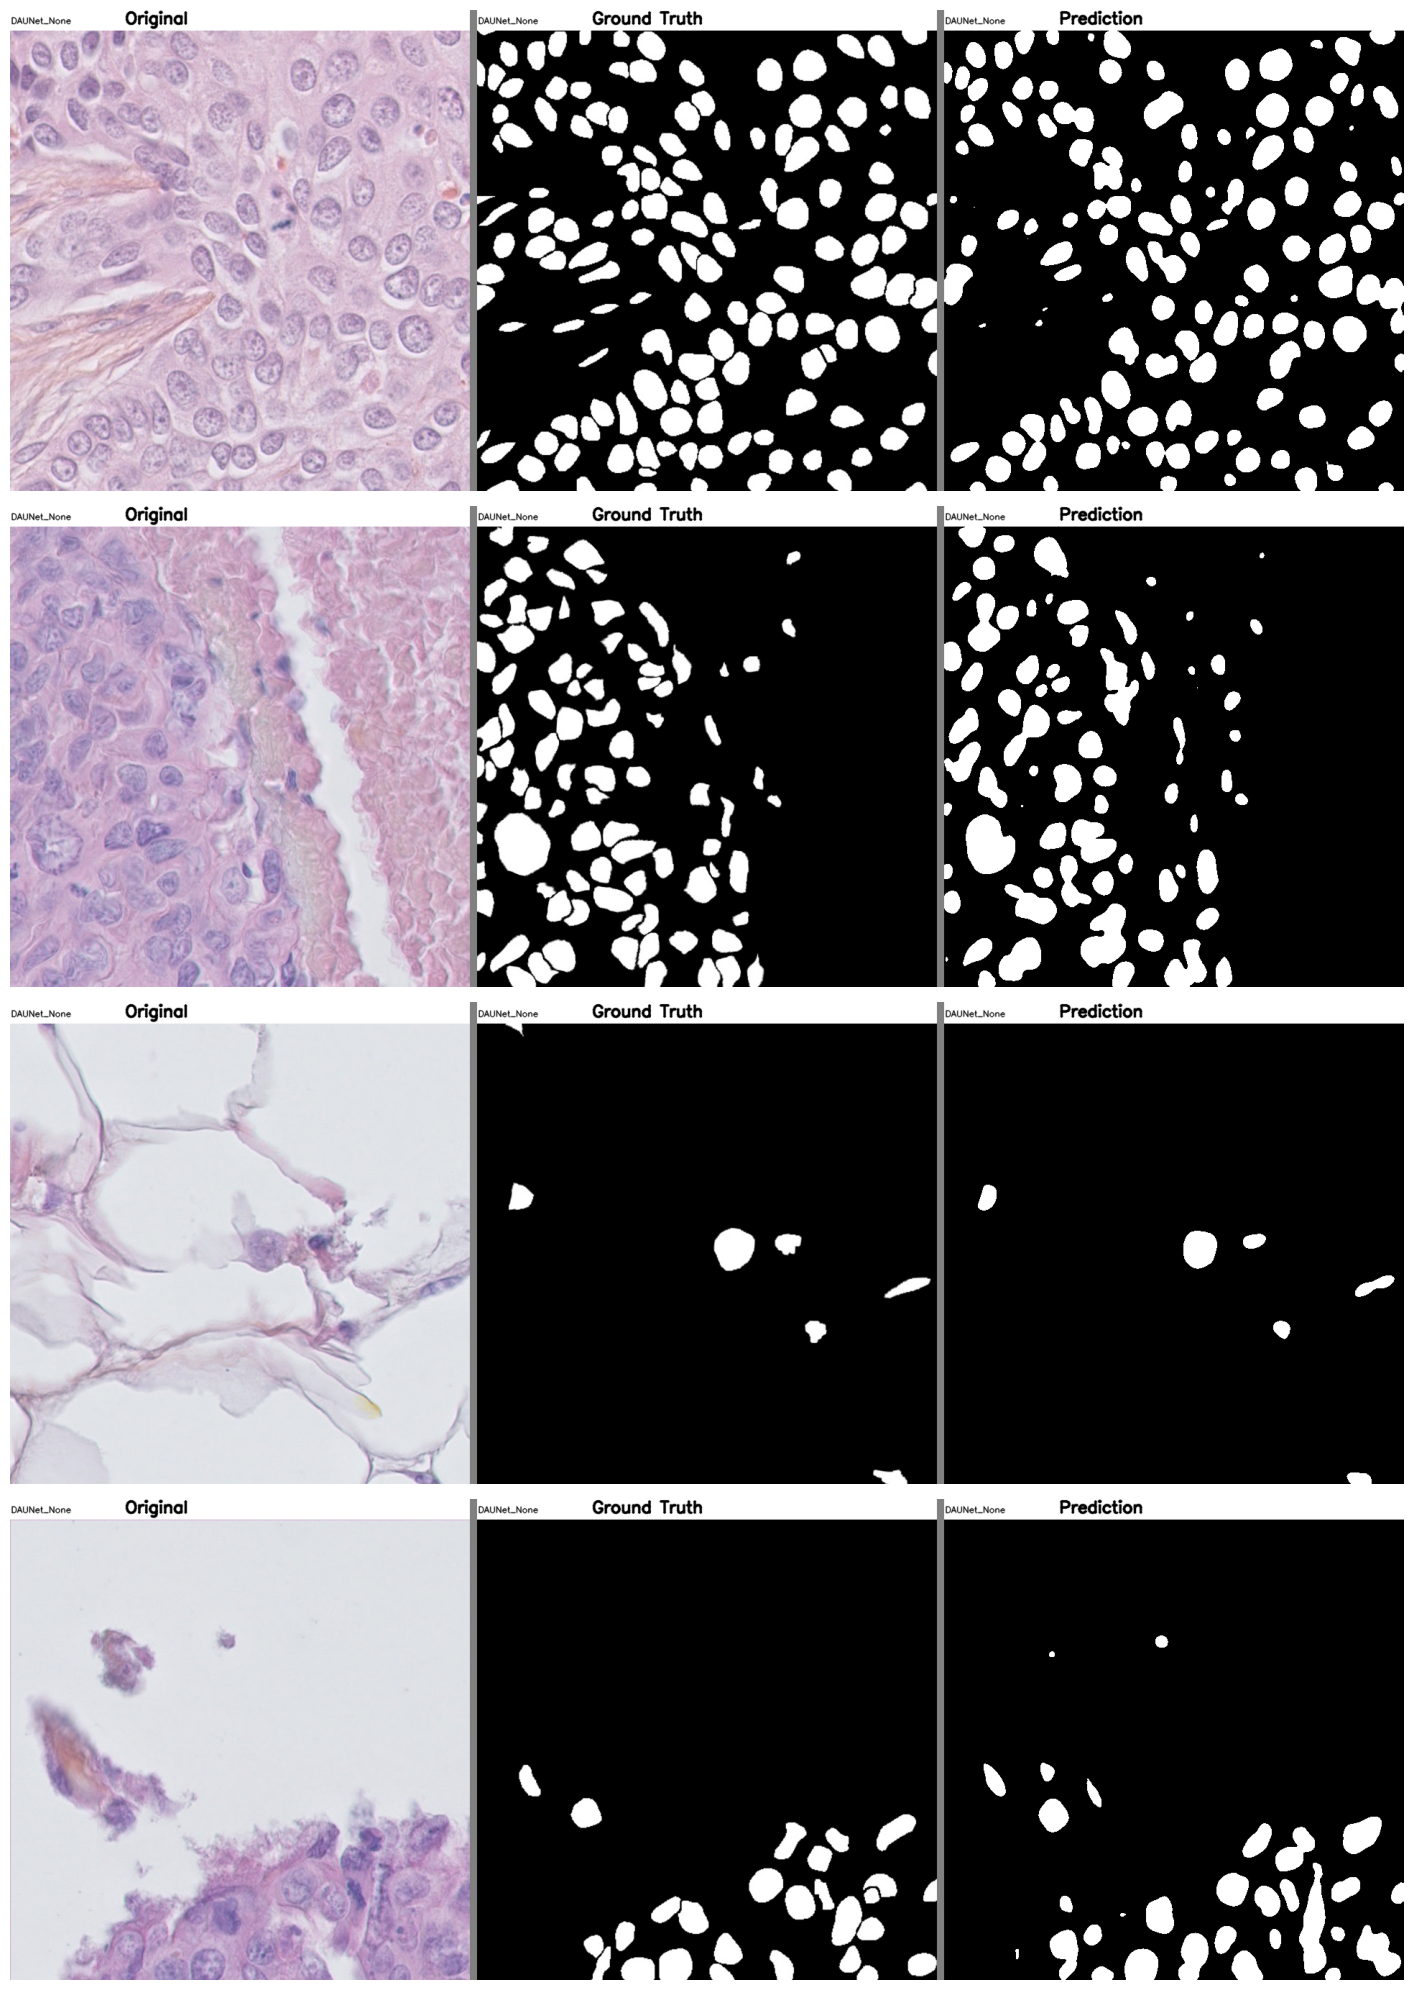

In [16]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
from glob import glob
import random

# Visualise the images and predicted masks on the test set
result_images = sorted(glob(f"{output_root}/results/*/*.png"))
if len(result_images) == 0:
    print(f"No images found in {output_root}/results/")
else:
    num_samples = min(4, len(result_images))
    sample_images = random.sample(result_images, num_samples)
    
    plt.figure(figsize=(20, 5 * num_samples))
    for i, img_path in enumerate(sample_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(num_samples, 1, i+1)
        plt.imshow(img)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()
